10.450583572185572
5.573526022256971
C - P          = 4.877058
S - K·exp(-rT) = 4.877058
Parity holds:    True


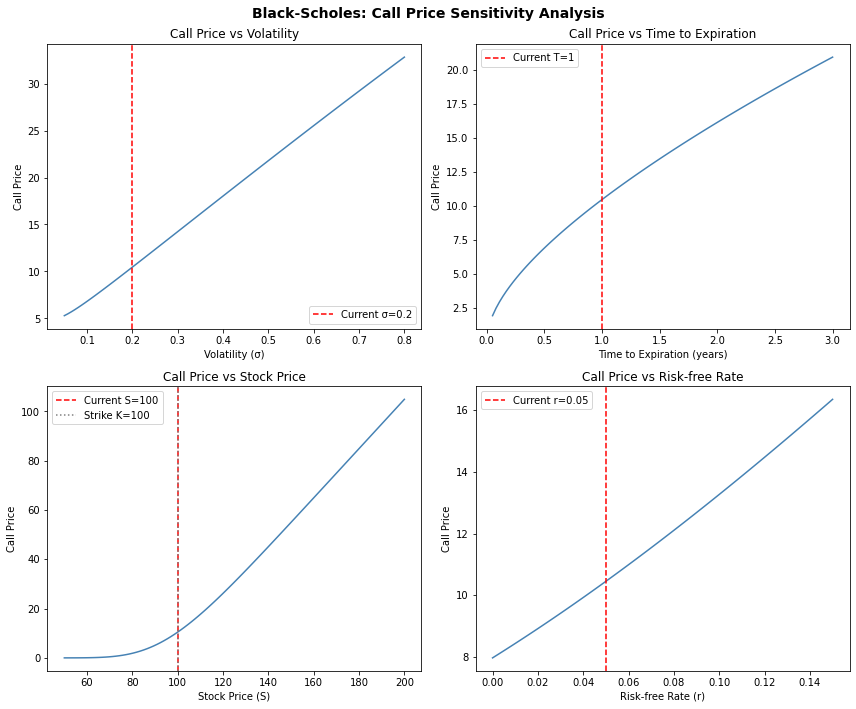

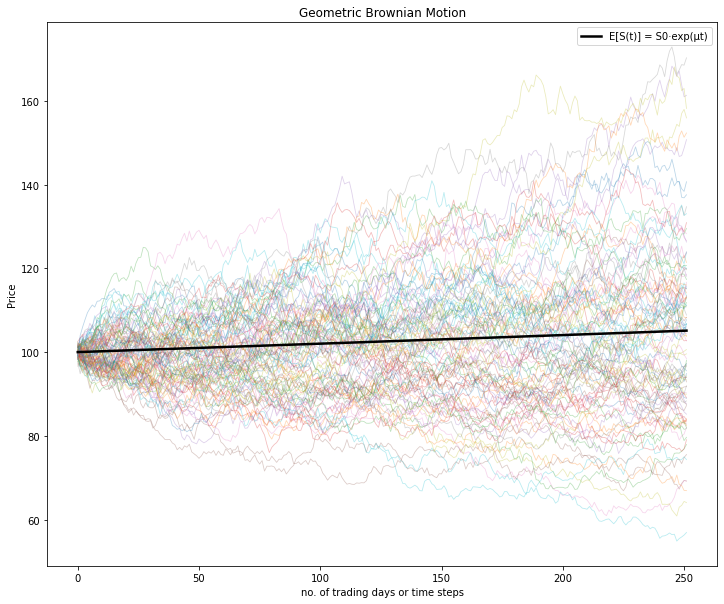

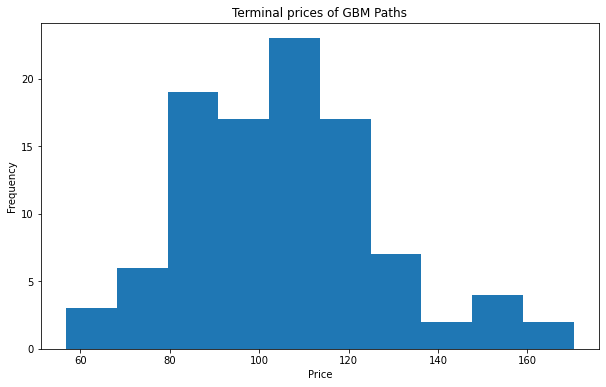

Terminal stats  —  Mean: 105.30  |  Std: 21.98  |  Analytical E[S(T)]: 105.13


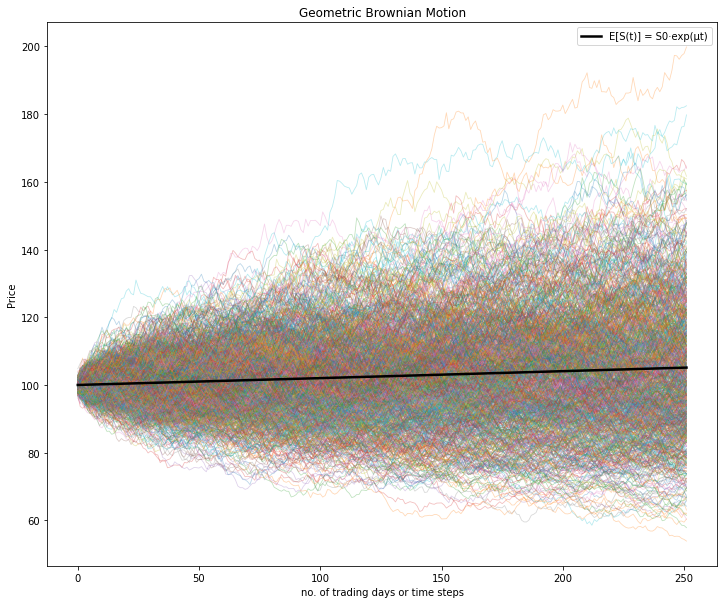

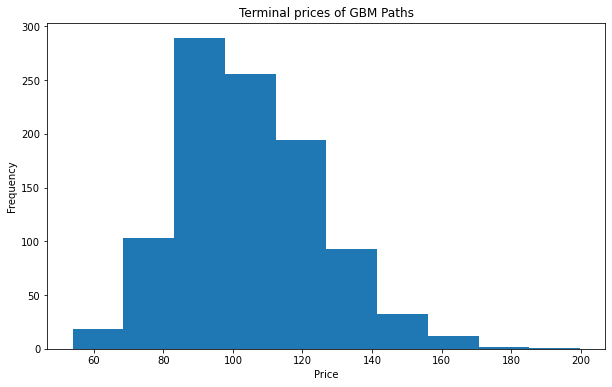

Terminal stats  —  Mean: 104.86  |  Std: 20.29  |  Analytical E[S(T)]: 105.13


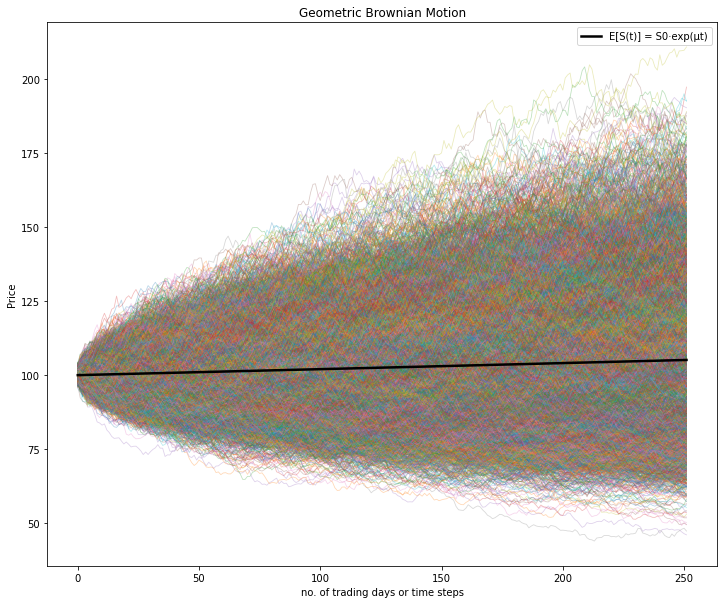

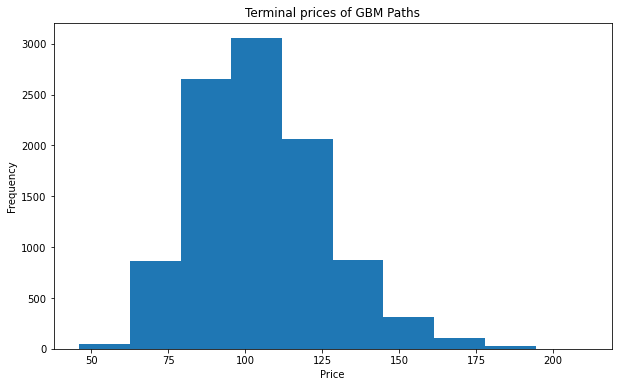

Terminal stats  —  Mean: 105.01  |  Std: 21.22  |  Analytical E[S(T)]: 105.13


In [1]:
import numpy as np
import pandas as pd
import math
import Black_Scholes as BS
import Geometric_Brownian_Motion as GBM
import matplotlib.pyplot as plt

In [2]:
## Monte Carlo price is the the discounted average terminal payoff
# simulate paths
# take payoff at expiry
# take mean of payoff
# discount back (multiply by exp(-rT))

In [3]:
def CalculatePayoff(terminal_prices, exercise_price):
    return np.maximum(terminal_prices - exercise_price, 0)

In [4]:
def CalculateMonteCarloPrice(number_of_paths, S0, sigma, T, N, K, r):
    simulated_paths = GBM.RunSimulationEngine(number_of_paths, S0, r, sigma, T, N)
    terminal_prices = GBM.GetTerminalPrices(simulated_paths)
    terminal_payoff = CalculatePayoff(terminal_prices, K)

    monte_carlo_price = terminal_payoff.mean() * math.exp(-1 * r * T)
    
    return monte_carlo_price

## optimized version, saves space
#def CalculateMonteCarloPriceFast(number_of_paths, S0, sigma, T, K, r):
#    # Only simulate terminal price — no need for full path
#    Z = np.random.standard_normal(number_of_paths)
#    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
#    payoff = np.maximum(ST - K, 0)
#    return payoff.mean() * np.exp(-r * T)

In [5]:
#defining initial parameters
S0 = 100      # Initial stock price
sigma = 0.20  # Volatility
T = 1         # Time horizon (years)
N = 252       # Number of days

K = 100       # Exercise Price
r = 0.05      # Risk free rate of return

In [6]:
#Simulate paths
number_of_paths = 100
monte_carlo_price = CalculateMonteCarloPrice(number_of_paths, S0, sigma, T, N, K, r)

print(monte_carlo_price)

13.17258117860098


In [7]:
monte_carlo_prices = pd.DataFrame(columns=['Number of Simulations', 'MC Price'])

number_of_paths_array = np.array([10, 100, 1000, 10000, 100000, 1000000])
monte_carlo_prices['Number of Simulations'] = number_of_paths_array

monte_carlo_prices['MC Price'] = monte_carlo_prices['Number of Simulations'].apply(CalculateMonteCarloPrice, args = (S0, sigma, T, N, K, r))

black_scholes_price = BS.calculateCallOptionPrice(S0, K, r, T, sigma)

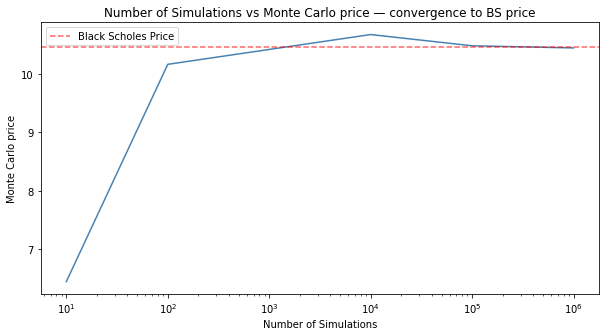

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(monte_carlo_prices['Number of Simulations'], monte_carlo_prices['MC Price'], color='steelblue')
plt.axhline(black_scholes_price, color='red',  linestyle='--', alpha=0.6, label='Black Scholes Price')
plt.xscale('log')
plt.title('Number of Simulations vs Monte Carlo price — convergence to BS price')
plt.xlabel('Number of Simulations')
plt.ylabel('Monte Carlo price')
plt.legend()
plt.show()

In [9]:
## for asian option
# use average price in place of terminal price

In [10]:
def GetAveragePrices(paths):
    return np.mean(paths, axis = 1)

In [11]:
def CalculateMonteCarloPriceAsianOptions(number_of_paths, S0, sigma, T, N, K, r):
    simulated_paths = GBM.RunSimulationEngine(number_of_paths, S0, r, sigma, T, N)
    mean_prices = GetAveragePrices(simulated_paths)
    mean_payoff = CalculatePayoff(mean_prices, K)

    monte_carlo_price = mean_payoff.mean() * math.exp(-1 * r * T)
    
    return monte_carlo_price

In [12]:
monte_carlo_prices_asian_options = pd.DataFrame(columns=['Number of Simulations', 'Price'])

number_of_paths_array = np.array([10, 100, 1000, 10000, 100000, 1000000])
monte_carlo_prices_asian_options['Number of Simulations'] = number_of_paths_array

monte_carlo_prices_asian_options['Price'] = monte_carlo_prices_asian_options['Number of Simulations'].apply(CalculateMonteCarloPriceAsianOptions, args = (S0, sigma, T, N, K, r))

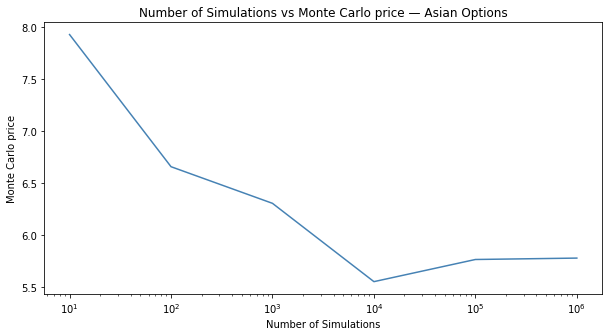

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(monte_carlo_prices_asian_options['Number of Simulations'], monte_carlo_prices_asian_options['Price'], color='steelblue')
plt.xscale('log')
plt.title('Number of Simulations vs Monte Carlo price — Asian Options')
plt.xlabel('Number of Simulations')
plt.ylabel('Monte Carlo price')
plt.show()